In [31]:
# %%
# ============================================================
# Cell 1. Imports and paths
# ============================================================
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import i0
from shapely.geometry import Point, Polygon

MEAN_GEOM_PATH = Path(
"/home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/mean_hidden_geometry.jsonl"
)

SEGMENT_KEY = "mean_hidden_segment_xy"   # alternatives: "gt_hidden_segment_xy"
FS_SIGNED = False
FS_RESOLUTION = 3

In [32]:
# %%
# ============================================================
# Cell 2. Helper functions, matching your FS implementation
# ============================================================
def load_jsonl_rows(path: Path):
    rows = []
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    poly = np.asarray(poly, dtype=float)

    if poly.ndim != 2:
        raise ValueError(f"Expected 2D polygon array, got shape {poly.shape}")

    if poly.shape[1] == 2:
        xy = poly.copy()
    elif poly.shape[0] == 2:
        xy = poly.T.copy()
    else:
        raise ValueError(f"Could not interpret polygon with shape {poly.shape}")

    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]

    return xy


def signed_polygon_area(xy):
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def ensure_ccw(xy):
    return xy[::-1].copy() if signed_polygon_area(xy) < 0 else xy.copy()


def resample_contour_arc_length(xy, n_points=256, closed=True):
    xy = np.asarray(xy, dtype=float)
    assert xy.ndim == 2 and xy.shape[1] == 2, f"Expected (N,2), got {xy.shape}"

    pts = xy.copy()

    if closed:
        if not np.allclose(pts[0], pts[-1]):
            pts = np.vstack([pts, pts[0]])

        diffs = np.diff(pts, axis=0)
        seglen = np.sqrt((diffs ** 2).sum(axis=1))
        s = np.concatenate([[0.0], np.cumsum(seglen)])
        total_len = s[-1]

        if total_len == 0:
            raise ValueError("Degenerate contour with zero total length")

        s_new = np.linspace(0.0, total_len, n_points, endpoint=False)
        x_new = np.interp(s_new, s, pts[:, 0])
        y_new = np.interp(s_new, s, pts[:, 1])
        return np.column_stack([x_new, y_new])

    diffs = np.diff(pts, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))
    s = np.concatenate([[0.0], np.cumsum(seglen)])
    total_len = s[-1]

    if total_len == 0:
        raise ValueError("Degenerate contour with zero total length")

    s_new = np.linspace(0.0, total_len, n_points)
    x_new = np.interp(s_new, s, pts[:, 0])
    y_new = np.interp(s_new, s, pts[:, 1])
    return np.column_stack([x_new, y_new])


def contourinfo(x, y, signed=False, resolution=3):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    if len(x) != len(y):
        raise ValueError("x and y must have equal length")

    N = len(x)
    b = 1.0

    if x[0] == x[-1] and y[0] == y[-1]:
        x = x[:-1]
        y = y[:-1]
        N -= 1
        open_curve = False
    else:
        open_curve = True

    normalmap = np.zeros((N, 2), dtype=float)
    surprisalmap = np.zeros(N, dtype=float)

    for j in range(N):
        xprev = 0.0
        yprev = 0.0
        xnext = 0.0
        ynext = 0.0

        for k in range(1, resolution + 1):
            prev_idx = j - k
            next_idx = j + k

            if prev_idx < 0:
                prev_idx += N
            if next_idx >= N:
                next_idx -= N

            xprev += x[prev_idx]
            yprev += y[prev_idx]
            xnext += x[next_idx]
            ynext += y[next_idx]

        xprev /= resolution
        yprev /= resolution
        xnext /= resolution
        ynext /= resolution

        vecprev = np.array([x[j] - xprev, y[j] - yprev], dtype=float)
        vecnext = np.array([xnext - x[j], ynext - y[j]], dtype=float)

        n1 = np.linalg.norm(vecprev)
        n2 = np.linalg.norm(vecnext)

        if n1 == 0 or n2 == 0:
            alpha = 0.0
        else:
            cosv = np.dot(vecprev, vecnext) / (n1 * n2)
            cosv = np.clip(cosv, -1.0, 1.0)
            alpha = np.arccos(cosv)

            cp = vecprev[0] * vecnext[1] - vecprev[1] * vecnext[0]
            alpha = np.sign(cp) * alpha

        if signed:
            shift = 2 * np.pi / (N / resolution)
            surprisal = -np.log(np.exp(b * np.cos(alpha - shift)) / (2 * np.pi * i0(b)))
        else:
            surprisal = -np.log(np.exp(b * np.cos(alpha)) / (2 * np.pi * i0(b)))

        if open_curve and ((j - resolution < 0) or (j + resolution >= N)):
            surprisal = 0.0

        tang = vecprev + vecnext
        tnorm = np.linalg.norm(tang)

        if tnorm == 0:
            normvec = np.array([0.0, 0.0], dtype=float)
        else:
            tang = tang / tnorm
            normvec = np.array([tang[1], -tang[0]], dtype=float)

        normalmap[j] = normvec
        surprisalmap[j] = surprisal

    return surprisalmap, normalmap, x, y, open_curve


def contourinfoplot_arrays(x, y, signed=False, resolution=3):
    surprisal_raw, normalmap, x_used, y_used, open_curve = contourinfo(
        x, y, signed=signed, resolution=resolution
    )

    s_norm = surprisal_raw.copy()
    r = np.ptp(s_norm)
    if r > 0:
        s_norm = (s_norm - s_norm.min()) / r
    else:
        s_norm[:] = 0.0

    needlesize = max(np.ptp(x_used), np.ptp(y_used)) / 10.0 if len(x_used) > 1 else 1.0

    normal_scaled = normalmap.copy()
    normal_scaled[:, 0] = s_norm * normal_scaled[:, 0]
    normal_scaled[:, 1] = s_norm * normal_scaled[:, 1]

    xnormals = np.column_stack([x_used, x_used + needlesize * normal_scaled[:, 0]])
    ynormals = np.column_stack([y_used, y_used + needlesize * normal_scaled[:, 1]])

    return s_norm, surprisal_raw, normalmap, xnormals, ynormals, open_curve


def arc_length_open_curve(xy):
    xy = np.asarray(xy, dtype=float)
    diffs = np.diff(xy, axis=0)
    seglen = np.sqrt((diffs ** 2).sum(axis=1))
    return float(seglen.sum())

In [33]:
# %%
# ============================================================
# Cell 3. Load saved mean hidden geometry
# ============================================================
rows = load_jsonl_rows(MEAN_GEOM_PATH)
row = rows[-1]

case_id = row["case_id"]

segment_xy = np.asarray(row[SEGMENT_KEY], dtype=float)
occluder_xy = np.asarray(row["occluder_xy"], dtype=float)
intersection_xy = np.asarray(row["intersection_points_xy"], dtype=float)
global_shape_xy = np.asarray(row["global_shape_filled_mean_xy"], dtype=float)

occ_poly = Polygon(occluder_xy)
if not occ_poly.is_valid:
    occ_poly = occ_poly.buffer(0)

segment_inside_occ = np.array([occ_poly.covers(Point(x, y)) for x, y in segment_xy], dtype=bool)

print("case_id:", case_id)
print("segment key:", SEGMENT_KEY)
print("n segment points:", len(segment_xy))
print("n occluder points:", len(occluder_xy))
print("all segment points inside occluder:", bool(segment_inside_occ.all()))
print("fraction segment points inside occluder:", float(segment_inside_occ.mean()))

case_id: bird_136_symmetrical_8_1
segment key: mean_hidden_segment_xy
n segment points: 250
n occluder points: 256
all segment points inside occluder: False
fraction segment points inside occluder: 0.992


In [34]:
# %%
# ============================================================
# Cell 4. Compute FS on the hidden segment only
# ============================================================
# This uses the hidden segment as an OPEN curve, which matches what it is.
segment_res = resample_contour_arc_length(segment_xy, n_points=len(segment_xy), closed=False)

s_norm_seg, surprisal_raw_seg, normalmap_seg, xnormals_seg, ynormals_seg, open_curve_seg = contourinfoplot_arrays(
    segment_res[:, 0],
    segment_res[:, 1],
    signed=FS_SIGNED,
    resolution=FS_RESOLUTION
)

seg_arclen = arc_length_open_curve(segment_res)

fs_segment_sum = float(np.sum(surprisal_raw_seg))
fs_segment_mean = float(np.mean(surprisal_raw_seg))
fs_segment_max = float(np.max(surprisal_raw_seg))
fs_segment_min = float(np.min(surprisal_raw_seg))
fs_segment_density = fs_segment_sum / seg_arclen if seg_arclen > 0 else np.nan

summary_df = pd.DataFrame([{
    "case_id": case_id,
    "segment_key": SEGMENT_KEY,
    "open_curve": open_curve_seg,
    "n_points": len(segment_res),
    "fs_sum": fs_segment_sum,
    "fs_mean": fs_segment_mean,
    "fs_max": fs_segment_max,
    "fs_min": fs_segment_min,
    "arc_length": seg_arclen,
    "fs_density": fs_segment_density,
}])

summary_df

,case_id,segment_key,open_curve,n_points,fs_sum,fs_mean,fs_max,fs_min,arc_length,fs_density
0,bird_136_symmetrical_8_1,mean_hidden_segment_xy,True,250,263.788518,1.055154,1.732293,0.0,63.223814,4.172297


In [35]:
# %%
# ============================================================
# Cell 5. Pointwise FS table along the hidden segment
# ============================================================
seg_diffs = np.diff(segment_res, axis=0)
seg_step = np.sqrt((seg_diffs ** 2).sum(axis=1))
seg_s = np.concatenate([[0.0], np.cumsum(seg_step)])
seg_s_norm = seg_s / seg_s[-1] if seg_s[-1] > 0 else seg_s

fs_pointwise_df = pd.DataFrame({
    "idx": np.arange(len(segment_res)),
    "x": segment_res[:, 0],
    "y": segment_res[:, 1],
    "s": seg_s,
    "s_norm": seg_s_norm,
    "fs_raw": surprisal_raw_seg,
    "fs_norm": s_norm_seg,
})

fs_pointwise_df.head(15)

,idx,x,y,s,s_norm,fs_raw,fs_norm
0,0,29.393436,76.544557,0.000000,0.000000,0.000000,0.000000
1,1,29.646948,76.562976,0.254180,0.004020,0.000000,0.000000
2,2,29.900461,76.581395,0.508361,0.008041,0.000000,0.000000
3,3,30.004075,76.376363,0.738087,0.011674,1.395872,0.805794
4,4,30.071326,76.131264,0.992244,0.015694,1.112364,0.642134
5,5,30.137638,75.885887,1.246424,0.019714,1.075500,0.620853
6,6,30.200326,75.639567,1.500596,0.023735,1.074267,0.620142
7,7,30.257426,75.391883,1.754776,0.027755,1.073948,0.619958
8,8,30.314526,75.144199,2.008956,0.031775,1.073941,0.619953
9,9,30.371298,74.896448,2.263129,0.035796,1.074224,0.620117


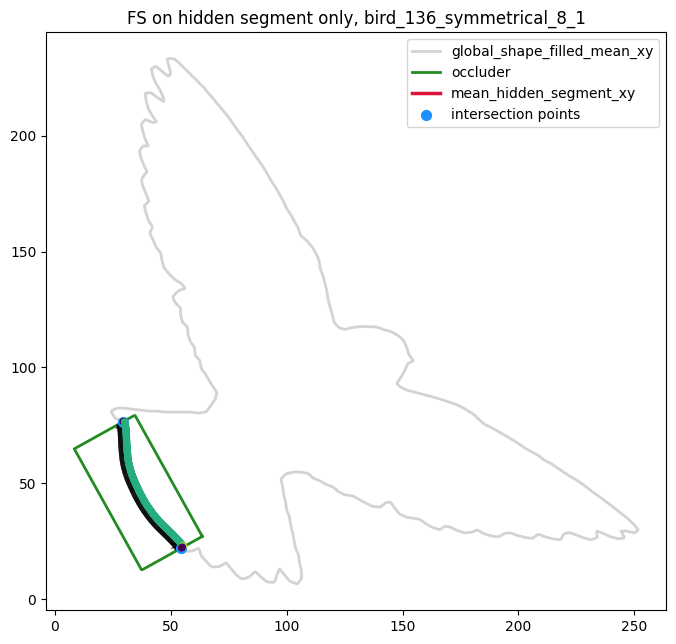

                 case_id            segment_key  open_curve  n_points     fs_sum  fs_mean   fs_max  fs_min  arc_length  fs_density
bird_136_symmetrical_8_1 mean_hidden_segment_xy        True       250 263.788518 1.055154 1.732293     0.0   63.223814    4.172297


In [36]:
# %%
# ============================================================
# Cell 6. Plot, hidden segment + occluder + FS needles
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

# full mean filled contour for context
ax.plot(
    global_shape_xy[:, 0],
    global_shape_xy[:, 1],
    color="lightgray",
    lw=2,
    label="global_shape_filled_mean_xy"
)

# occluder
occ_closed = np.vstack([occluder_xy, occluder_xy[0]])
ax.plot(
    occ_closed[:, 0],
    occ_closed[:, 1],
    color="forestgreen",
    lw=2,
    label="occluder"
)

# hidden segment
ax.plot(
    segment_res[:, 0],
    segment_res[:, 1],
    color="crimson",
    lw=2.5,
    label=SEGMENT_KEY
)

# intersection points
ax.scatter(
    intersection_xy[:, 0],
    intersection_xy[:, 1],
    s=50,
    color="dodgerblue",
    zorder=4,
    label="intersection points"
)

# FS needles on hidden segment
for i in range(len(segment_res)):
    ax.plot(xnormals_seg[i], ynormals_seg[i], color="black", lw=0.9, alpha=0.8)

ax.scatter(
    segment_res[:, 0],
    segment_res[:, 1],
    c=surprisal_raw_seg,
    s=18,
    zorder=5
)

ax.set_aspect("equal")
ax.set_title(f"FS on hidden segment only, {case_id}")
ax.legend()
plt.show()

print(summary_df.to_string(index=False))

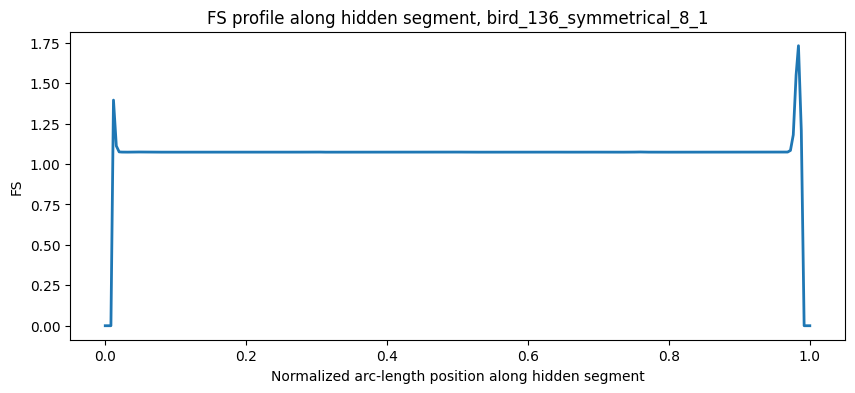

In [37]:
# %%
# ============================================================
# Cell 7. Optional, plot FS as a function of arc-length position
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(seg_s_norm, surprisal_raw_seg, lw=2)
ax.set_xlabel("Normalized arc-length position along hidden segment")
ax.set_ylabel("FS")
ax.set_title(f"FS profile along hidden segment, {case_id}")
plt.show()

In [38]:
# %%
# ============================================================
# Cell. Center FS so that a straight segment has value 0
# ============================================================
from scipy.special import i0
import numpy as np

def fs_straight_baseline(b=1.0):
    return -np.log(np.exp(b) / (2 * np.pi * i0(b)))

FS_BASELINE_STRAIGHT = fs_straight_baseline(b=1.0)
print("Straight-line FS baseline:", FS_BASELINE_STRAIGHT)

surprisal_centered = surprisal_raw_seg.copy()
mask_valid = np.ones_like(surprisal_centered, dtype=bool)

# optional. keep endpoint-forced zeros as NaN so they don't drag the mean down
mask_valid[:FS_RESOLUTION] = False
mask_valid[-FS_RESOLUTION:] = False

surprisal_centered[mask_valid] = surprisal_centered[mask_valid] - FS_BASELINE_STRAIGHT
surprisal_centered[~mask_valid] = np.nan

print("Centered FS mean:", np.nanmean(surprisal_centered))
print("Centered FS max :", np.nanmax(surprisal_centered))
print("Centered FS min :", np.nanmin(surprisal_centered))

Straight-line FS baseline: 1.073791424916524
Centered FS mean: 0.007309060594867357
Centered FS max : 0.658501399960508
Centered FS min : 7.528377921062201e-11


In [39]:
# %%
# ============================================================
# Cell. Save FS results next to mean_hidden_geometry.jsonl
# ============================================================
from pathlib import Path
import json
import numpy as np
import pandas as pd
from scipy.special import i0

# -----------------------------
# 1. Resolve save directory
# -----------------------------
SAVE_DIR = MEAN_GEOM_PATH.parent

jsonl_path = SAVE_DIR / "fs_hidden_segment.jsonl"
csv_path   = SAVE_DIR / "fs_hidden_segment_pointwise.csv"

# -----------------------------
# 2. Compute centered FS
# -----------------------------
def fs_straight_baseline(b=1.0):
    return -np.log(np.exp(b) / (2 * np.pi * i0(b)))

FS_BASELINE = fs_straight_baseline(b=1.0)

valid_mask = np.ones_like(surprisal_raw_seg, dtype=bool)
valid_mask[:FS_RESOLUTION] = False
valid_mask[-FS_RESOLUTION:] = False

fs_raw = surprisal_raw_seg.copy()
fs_centered = surprisal_raw_seg.copy()

fs_centered[valid_mask] = fs_centered[valid_mask] - FS_BASELINE
fs_centered[~valid_mask] = np.nan

# -----------------------------
# 3. Summary row (JSONL)
# -----------------------------
summary_row = {
    "case_id": case_id,
    "segment_key": SEGMENT_KEY,

    "n_points": int(len(segment_res)),
    "fs_resolution": int(FS_RESOLUTION),
    "fs_signed": bool(FS_SIGNED),

    "fs_baseline_straight": float(FS_BASELINE),
    "arc_length": float(seg_arclen),

    # raw FS
    "fs_raw_sum": float(np.nansum(fs_raw[valid_mask])),
    "fs_raw_mean": float(np.nanmean(fs_raw[valid_mask])),
    "fs_raw_max": float(np.nanmax(fs_raw[valid_mask])),
    "fs_raw_min": float(np.nanmin(fs_raw[valid_mask])),

    # centered FS
    "fs_centered_sum": float(np.nansum(fs_centered)),
    "fs_centered_mean": float(np.nanmean(fs_centered)),
    "fs_centered_max": float(np.nanmax(fs_centered)),
    "fs_centered_min": float(np.nanmin(fs_centered)),
}

with open(jsonl_path, "a") as f:
    f.write(json.dumps(summary_row) + "\n")

print("Appended summary to:", jsonl_path)

# -----------------------------
# 4. Pointwise CSV (overwrite)
# -----------------------------
seg_diffs = np.diff(segment_res, axis=0)
seg_step = np.sqrt((seg_diffs ** 2).sum(axis=1))
seg_s = np.concatenate([[0.0], np.cumsum(seg_step)])
seg_s_norm = seg_s / seg_s[-1] if seg_s[-1] > 0 else seg_s

df = pd.DataFrame({
    "case_id": case_id,
    "idx": np.arange(len(segment_res)),
    "x": segment_res[:, 0],
    "y": segment_res[:, 1],
    "s": seg_s,
    "s_norm": seg_s_norm,
    "fs_raw": fs_raw,
    "fs_centered": fs_centered,
    "fs_norm": s_norm_seg,
    "valid": valid_mask,
})

df.to_csv(csv_path, index=False)

print("Saved pointwise CSV to:", csv_path)

Appended summary to: /home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/fs_hidden_segment.jsonl
Saved pointwise CSV to: /home/hschatzle/monte-carlo-selection/results/sweep/bgmm_bird_136_symmetrical_shape_8/bird_136_symmetrical_8_1/fs_hidden_segment_pointwise.csv
